In [14]:
import numpy as np
import matplotlib.pyplot as plt

from fractions import Fraction

import astropy.units as u
import astropy.constants.codata2018 as cst

Gauss = u.g ** Fraction(1, 2) * u.cm ** (-Fraction(1, 2)) * u.s ** (-1)
uGauss = 1e-6 * Gauss

In [41]:
dif_cof15 = np.loadtxt("1e15_ortho.txt", delimiter=",", skiprows=1)
dif_cof16 = np.loadtxt("1e16_ortho.txt", delimiter=",", skiprows=1)
dif_cof416 = np.loadtxt("5e16_ortho.txt", delimiter=",", skiprows=1)
dif_cof17 = np.loadtxt("1e17_ortho.txt", delimiter=",", skiprows=1)

In [42]:
t15, dif15 = (dif_cof15[:, 0] * u.kpc / cst.c).to(u.yr), dif_cof15[:, 1] * u.cm**2 / u.s
t16, dif16 = (dif_cof16[:, 0] * u.kpc / cst.c).to(u.yr), dif_cof16[:, 1] * u.cm**2 / u.s
t416, dif416 = (dif_cof416[:, 0] * u.kpc / cst.c).to(u.yr), dif_cof416[:, 1] * u.cm**2 / u.s
t17, dif17 = (dif_cof17[:, 0] * u.kpc / cst.c).to(u.yr), dif_cof17[:, 1] * u.cm**2 / u.s

### Orthogonal diffusion coefficient

$$ R_L = \dfrac{E_\perp}{eB} $$

In [43]:
def larmor_radius(E, B):
    return (E / (cst.e_gauss * B)).to(u.lyr)

larmor_radius(10*u.PeV, 1*uGauss)

<Quantity 35.25775268 lyr>

Text(0, 0.5, 'Diffusion coefficient (c * yr)')

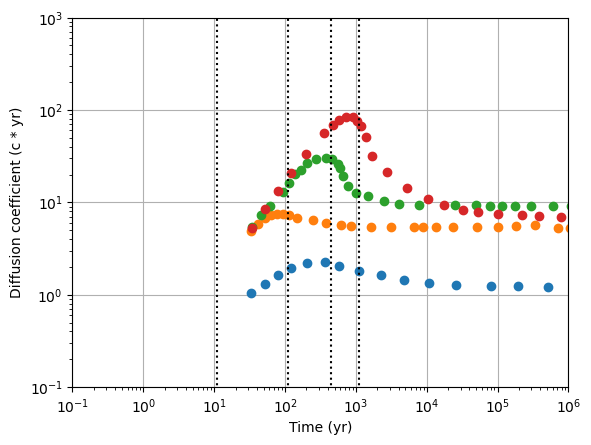

In [44]:
plt.loglog(t15, (dif15).to(u.lyr**2/u.yr), marker="o", linewidth=0)
plt.loglog(t16, (dif16).to(u.lyr**2/u.yr), marker="o", linewidth=0)
plt.loglog(t416, (dif416).to(u.lyr**2/u.yr), marker="o", linewidth=0)
plt.loglog(t17, (dif17).to(u.lyr**2/u.yr), marker="o", linewidth=0)
plt.grid(True)

bfield = 1 * uGauss
plt.vlines([np.pi*larmor_radius(1*u.PeV, bfield).to_value(u.lyr),
            np.pi*larmor_radius(10*u.PeV, bfield).to_value(u.lyr),
            np.pi*larmor_radius(40*u.PeV, bfield).to_value(u.lyr),
            np.pi*larmor_radius(100*u.PeV, bfield).to_value(u.lyr)],
           1e-2, 1e4, colors="k", linestyles="dotted")

plt.xlim(0.1, 1e6)
plt.xlabel("Time (yr)")

plt.ylim(0.1, 1e3)
plt.ylabel("Diffusion coefficient (c * yr)")

Text(0, 0.5, 'Distance (lyr)')

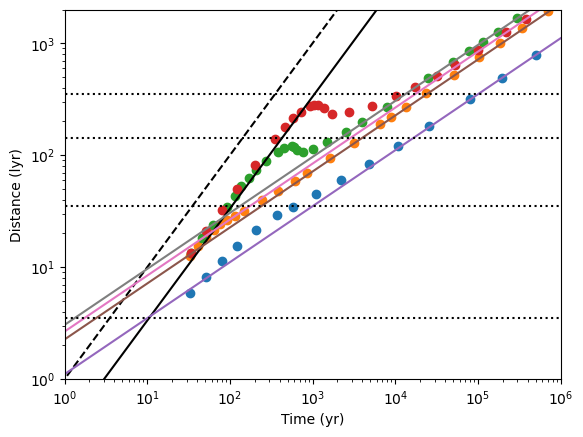

In [46]:

t0 = np.logspace(-2, 6, 100) * u.yr

plt.loglog(t15, np.sqrt(dif15 * t15).to(u.lyr), marker="o", linewidth=0)
plt.loglog(t16, np.sqrt(dif16 * t16).to(u.lyr), marker="o", linewidth=0)
plt.loglog(t416, np.sqrt(dif416 * t416).to(u.lyr), marker="o", linewidth=0)
plt.loglog(t17, np.sqrt(dif17 * t17).to(u.lyr), marker="o", linewidth=0)

plt.loglog(t0, (cst.c * t0).to(u.lyr), linestyle="dashed", color='k')
plt.loglog(t0, (cst.c/3 * t0).to(u.lyr), color='k')

plt.loglog(t0, np.sqrt(dif15[-1] * t0).to(u.lyr))
plt.loglog(t0, np.sqrt(dif16[-1] * t0).to(u.lyr))
plt.loglog(t0, np.sqrt(dif17[-1] * t0).to(u.lyr))
plt.loglog(t0, np.sqrt(dif416[-1] * t0).to(u.lyr))

plt.hlines([larmor_radius(1*u.PeV, bfield).to_value(u.lyr),
            larmor_radius(10*u.PeV, bfield).to_value(u.lyr),
            larmor_radius(40*u.PeV, bfield).to_value(u.lyr),
            larmor_radius(100*u.PeV, bfield).to_value(u.lyr)],
           1e-2, 1e7, colors="k", linestyles="dotted")

plt.xlim(1, 1e6)
plt.xlabel("Time (yr)")

plt.ylim(1, 2e3)
plt.ylabel("Distance (lyr)")